# Breast Cancer Classification: A Cost-Sensitive Support Vector Machine (SVM) Approach

## Project Overview
In medical diagnostics, the consequences of misclassification are rarely symmetric. While predicting a false positive (diagnosing a healthy patient with cancer) causes unnecessary stress and further testing, predicting a false negative (missing a malignant tumor) can be life-threatening. 

**Objective:** The goal of this project is to build a robust Support Vector Machine (SVM) classifier to detect breast cancer using features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. More importantly, this notebook demonstrates how to transition from a "standard" high-accuracy model to a **cost-sensitive model** optimized for the medical domain by aggressively minimizing false negatives.

**Key Techniques Demonstrated:**
* Data Preprocessing and Standardization
* K-Fold Cross Validation from scratch
* Baseline Linear SVM Implementation
* Cost-Sensitive Learning & Hyperparameter Tuning (Grid Search)
* Confusion Matrix Visualization using `ggplot2`

In [77]:
options(repr.plot.width = 24, repr.plot.height = 15)

In [78]:
library(tidyverse)
library(e1071)
library(performance)
library(caret)
library(boot)

## 1. Data Ingestion & Preprocessing

First, we load the dataset and perform standard structural checks. To prepare the data for our modeling phase, we must handle irrelevant features and scale our inputs. 

**Why Standardize?** Support Vector Machines act as spatial margin maximizers. Because SVMs use distance algorithms to find the optimal hyperplane, they are highly sensitive to the scale of the input features. If one feature has a range of `0 to 1` and another has a range of `100 to 1000`, the latter will dominate the distance calculations. Therefore, we will center and scale all numeric columns to have a mean of 0 and a variance of 1.

In [79]:
set.seed(123)

breast_cancer_raw <- read.csv('C:/Users/conne/Documents/GitHub/project_dev/R/breast_cancer_app/breast_cancer.csv', header=T)

str(breast_cancer_raw)

'data.frame':	569 obs. of  33 variables:
 $ id                     : int  842302 842517 84300903 84348301 84358402 843786 844359 84458202 844981 84501001 ...
 $ diagnosis              : chr  "M" "M" "M" "M" ...
 $ radius_mean            : num  18 20.6 19.7 11.4 20.3 ...
 $ texture_mean           : num  10.4 17.8 21.2 20.4 14.3 ...
 $ perimeter_mean         : num  122.8 132.9 130 77.6 135.1 ...
 $ area_mean              : num  1001 1326 1203 386 1297 ...
 $ smoothness_mean        : num  0.1184 0.0847 0.1096 0.1425 0.1003 ...
 $ compactness_mean       : num  0.2776 0.0786 0.1599 0.2839 0.1328 ...
 $ concavity_mean         : num  0.3001 0.0869 0.1974 0.2414 0.198 ...
 $ concave.points_mean    : num  0.1471 0.0702 0.1279 0.1052 0.1043 ...
 $ symmetry_mean          : num  0.242 0.181 0.207 0.26 0.181 ...
 $ fractal_dimension_mean : num  0.0787 0.0567 0.06 0.0974 0.0588 ...
 $ radius_se              : num  1.095 0.543 0.746 0.496 0.757 ...
 $ texture_se             : num  0.905 0.734 0.787 1

In [80]:
breast_cancer_raw <- breast_cancer_raw %>% select(!'id' & !'X') # These columns have no use
breast_cancer_raw$diagnosis <- as.factor(breast_cancer_raw$diagnosis) # Turn diagnosis into a factor

In [ ]:
# Standardize numeric columns
breast_cancer_clean <- breast_cancer_raw %>%
  mutate(
    across(
      where(is.numeric),
      ~ scale(.x)
    )
  )

scaling_parameters <- breast_cancer_raw %>%
  summarise(
    across(
      where(is.numeric),
      list(mean = ~mean(.x, na.rm = TRUE), sd = ~sd(.x, na.rm = TRUE))
    )
  )
# Calculate the mean for each column
breast_cancer_clean %>% select(where(is.numeric)) %>% sapply(FUN = mean, na.rm=T)

            radius_mean            texture_mean          perimeter_mean               area_mean         smoothness_mean        compactness_mean          concavity_mean 
          -1.379776e-16            6.157678e-17           -1.190559e-16            1.219971e-16            1.618800e-16           -7.605173e-17            3.929080e-17 
    concave.points_mean           symmetry_mean  fractal_dimension_mean               radius_se              texture_se            perimeter_se                 area_se 
          -5.337457e-17            1.679646e-16            4.810260e-16            3.721164e-17           -1.065855e-16            1.074950e-16            2.873226e-17 
          smoothness_se          compactness_se            concavity_se       concave.points_se             symmetry_se    fractal_dimension_se            radius_worst 
           1.290824e-16           -1.610869e-17           -5.978051e-17            7.922107e-18            9.126277e-17            1.564424e-18           -

In [82]:
# Calculate the variance for each column
breast_cancer_clean %>% select(where(is.numeric)) %>% sapply(FUN = var, na.rm=T)

            radius_mean            texture_mean          perimeter_mean               area_mean         smoothness_mean        compactness_mean          concavity_mean 
                      1                       1                       1                       1                       1                       1                       1 
    concave.points_mean           symmetry_mean  fractal_dimension_mean               radius_se              texture_se            perimeter_se                 area_se 
                      1                       1                       1                       1                       1                       1                       1 
          smoothness_se          compactness_se            concavity_se       concave.points_se             symmetry_se    fractal_dimension_se            radius_worst 
                      1                       1                       1                       1                       1                       1            

## 2. Model Evaluation Strategy: K-Fold Cross Validation

To ensure our model's performance metrics are robust and not merely the result of a lucky train-test split, we will implement **k-fold cross-validation** ($k=10$). 

Instead of relying on out-of-the-box wrappers, I have defined a custom function to iterate through the folds, train a Linear SVM on the training set, and evaluate it on the holdout fold. This allows for fine-grained control over our evaluation loop and provides a clear view into the model's out-of-sample performance.

In [83]:
# K is the number of folds performed
svm_linear <- function(df, k=10){

  actual_linear = list()
  predict_linear = list()
  folds = createFolds(df$diagnosis, k=k, list=T, returnTrain=F)

  for(i in 1:k){

    print(paste('Fold:', i, sep=' '))

    test_indices <- folds[[i]]

    test <- df[test_indices,]
    train <- df[-test_indices,]

    model_linear <- svm(diagnosis~., data=train, kernel='linear')

    # Store results
    actual_linear[[i]] <- test$diagnosis 
    predict_linear[[i]] <- predict(model_linear, test)
  }
  return(list(actual_linear=actual_linear, predict_linear=predict_linear))
}

In [84]:
results <- svm_linear(breast_cancer_raw)

# Take results and put them into a dataframe
results_linear <- data.frame(
  'Actuals' =
  unlist(results$actual_linear),
  'Predicted' =
  unlist(results$predict_linear)
  ) %>% # Convert actuals and predicted into numeric variables so we can plot a heatmap
  mutate( 
    Actuals = as.numeric(Actuals),
    Predicted = as.numeric(Predicted)
  ) %>% # Convert to a table to create a confusion matrix
  table() %>%
  as.data.frame() %>% # Convert back into a data frame to feed into ggplot2
  mutate( # Turn (1, 2) into corresponding diagnosis for readability
    Actuals = ifelse(Actuals==1, 'Benign', 'Malignant'),
    Predicted = ifelse(Predicted==1, 'Benign', 'Malignant')
  )

[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"


In [85]:
# Lets also create a percent accuracy result for our visual
confusion_matrix_to_percent_accuracy <- function(df){
  correct_predictions = df %>% filter(Actuals == Predicted) %>% select('Freq') %>% sum()
  total = sum(df$Freq)
  accuracy = correct_predictions/total
  return(accuracy)
}

accuracy <- confusion_matrix_to_percent_accuracy(results_linear)
accuracy <- round(accuracy*100, 2)

## 3. Baseline Model Performance

With our 10-fold cross-validation complete, we consolidate our 569 predictions and compare them against the actual labels. Let's visualize the results using a confusion matrix heatmap. 

While raw accuracy is a standard metric, a visual matrix allows us to clearly distinguish between our True Positives, True Negatives, False Positives, and False Negatives.

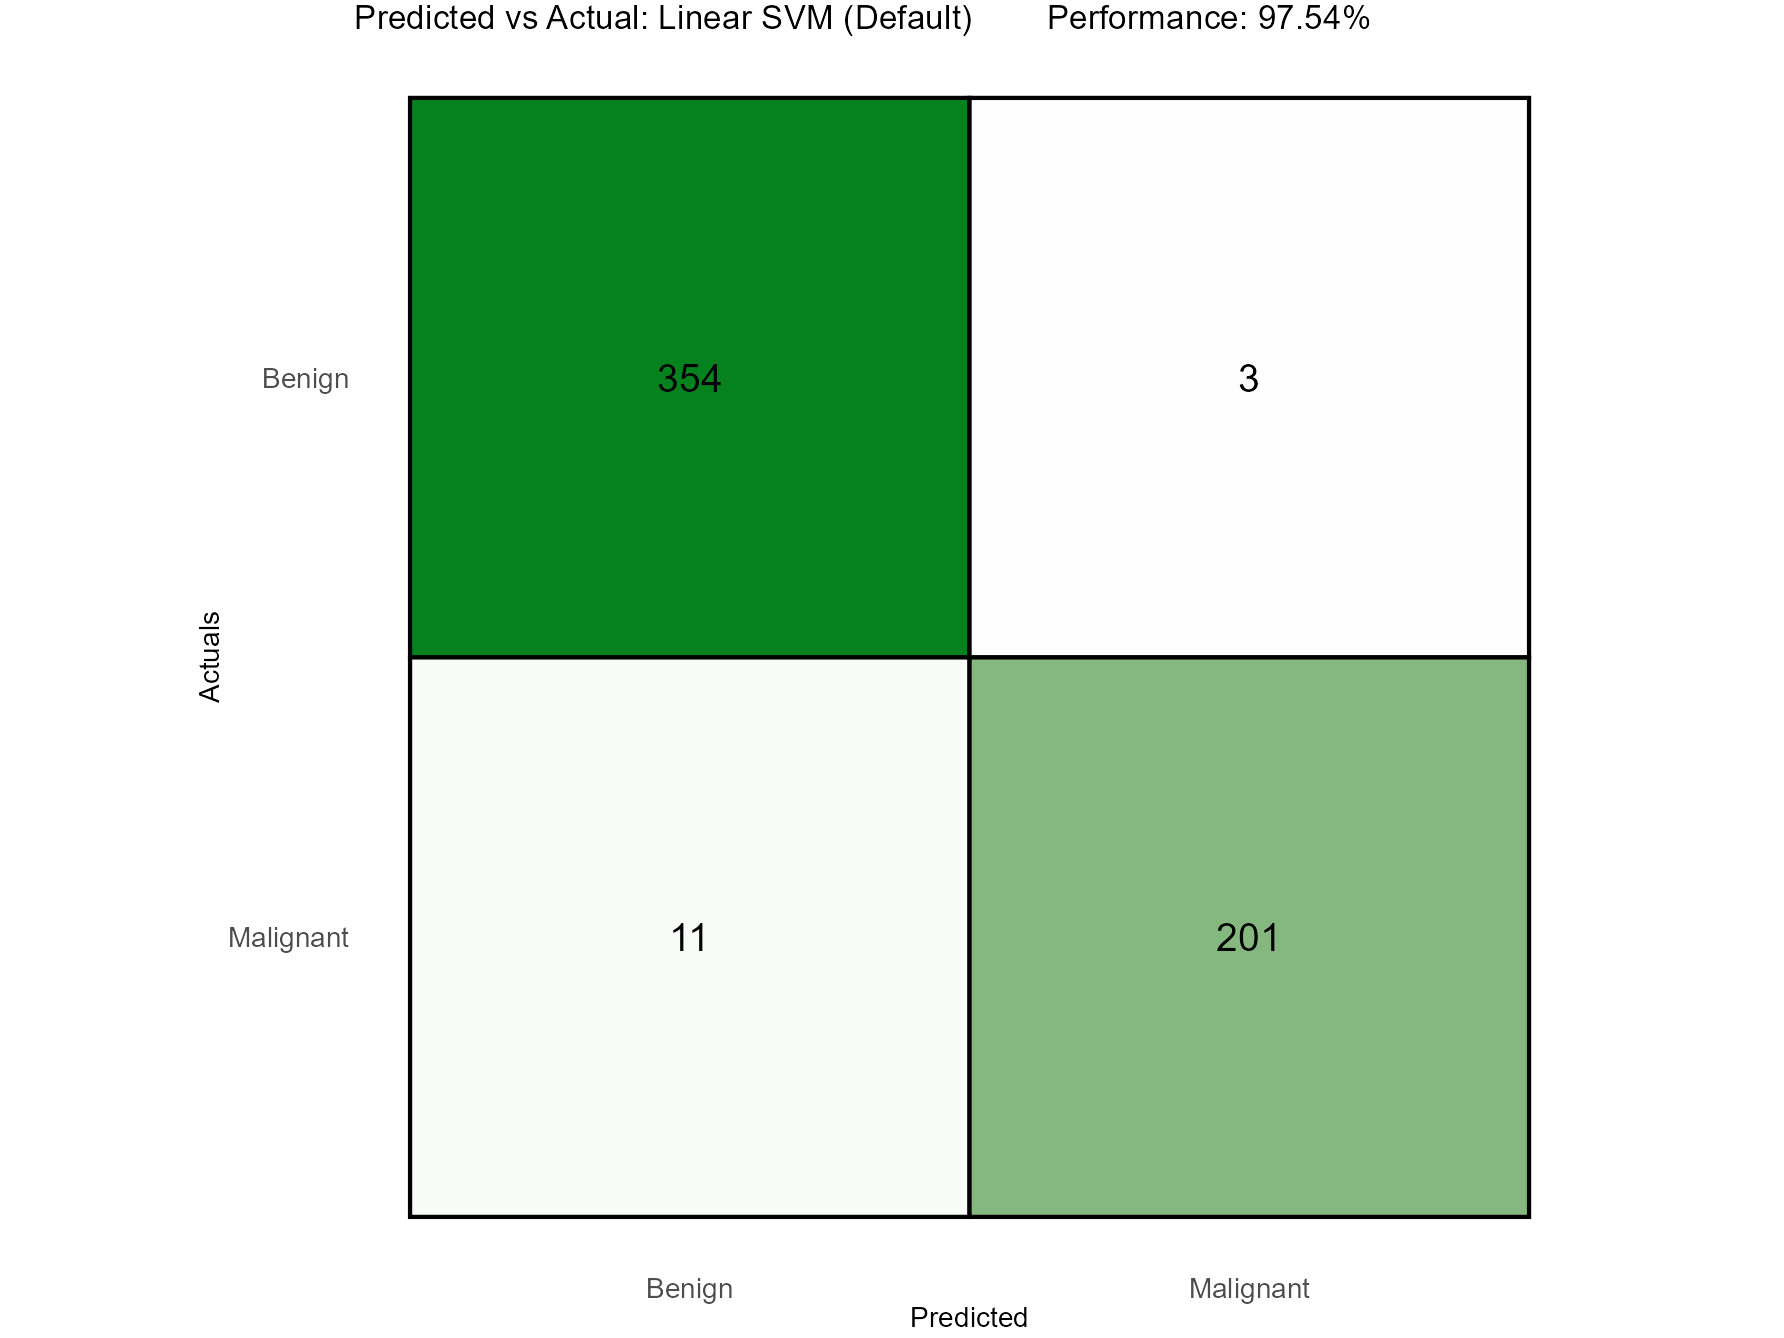

In [86]:
# plot a heatmap
ggplot(results_linear, aes(Predicted, Actuals)) +
  theme_minimal() +
  theme(
    title = element_text(size=28),
    axis.title = element_text(size=28),
    axis.text = element_text(size=28),
    legend.position = 'None',
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  geom_tile(aes(fill = Freq), linewidth=2, color='black') +
  geom_text(aes(label = Freq), size = 14) +
  scale_fill_gradient2(
    low = '#dbffe2',
    high = '#05821e'
  ) +
  scale_y_discrete(limits=rev) +
  ggtitle(paste('Predicted vs Actual: Linear SVM (Default)        Performance: ', accuracy, '%', sep = ''))

## 4. The Domain Problem: Addressing False Negatives

**Analyzing the Baseline:**
Our baseline linear SVM achieves an impressive ~97.5% overall accuracy. However, in the context of oncology, overall accuracy is a misleading metric. Looking at the confusion matrix, we see a notable number of **False Negatives** (predicting a tumor is Benign when it is actually Malignant). 

**Cost-Sensitive Learning:**
In a clinical setting, missing a malignant diagnosis is arguably the worst possible outcome. To fix this, we cannot treat all errors equally. We must introduce an asymmetric cost parameter that heavily penalizes the model for misclassifying malignant tumors. By assigning a higher weight/penalty to 'Malignant' errors, we force the SVM's hyperplane to shift, prioritizing *Sensitivity* (Recall) over *Specificity*.

In [87]:
# Re-define the function to allow us to adjust how much we penalise 'Malignent'
svm_linear <- function(df, k_folds=10, cost_M=25, cost_B=1){

  actual_linear = list()
  predict_linear = list()
  folds = createFolds(df$diagnosis, k=k_folds, list=T, returnTrain=F)
  weights = c('M' = cost_M, 'B' = cost_B)

  for(i in 1:k_folds){

    print(paste('Fold:', i, sep=' '))

    test_indices <- folds[[i]]

    test <- df[test_indices,]
    train <- df[-test_indices,]

    model_linear <- svm(diagnosis~., data=train, kernel='linear', class.weights = weights)

    # Store results
    actual_linear[[i]] <- test$diagnosis 
    predict_linear[[i]] <- predict(model_linear, test)
  }
  return(list(actual_linear=actual_linear, predict_linear=predict_linear))
}

In [88]:
# Repeat previous steps with the new function
results <- svm_linear(breast_cancer_raw)

results_linear <- data.frame(
  'Actuals' =
  unlist(results$actual_linear),
  'Predicted' =
  unlist(results$predict_linear)
  ) %>%
  mutate( 
    Actuals = as.numeric(Actuals),
    Predicted = as.numeric(Predicted)
  ) %>%
  table() %>%
  as.data.frame() %>%
  mutate(
    Actuals = ifelse(Actuals==1, 'Benign', 'Malignant'),
    Predicted = ifelse(Predicted==1, 'Benign', 'Malignant')
  )

[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"


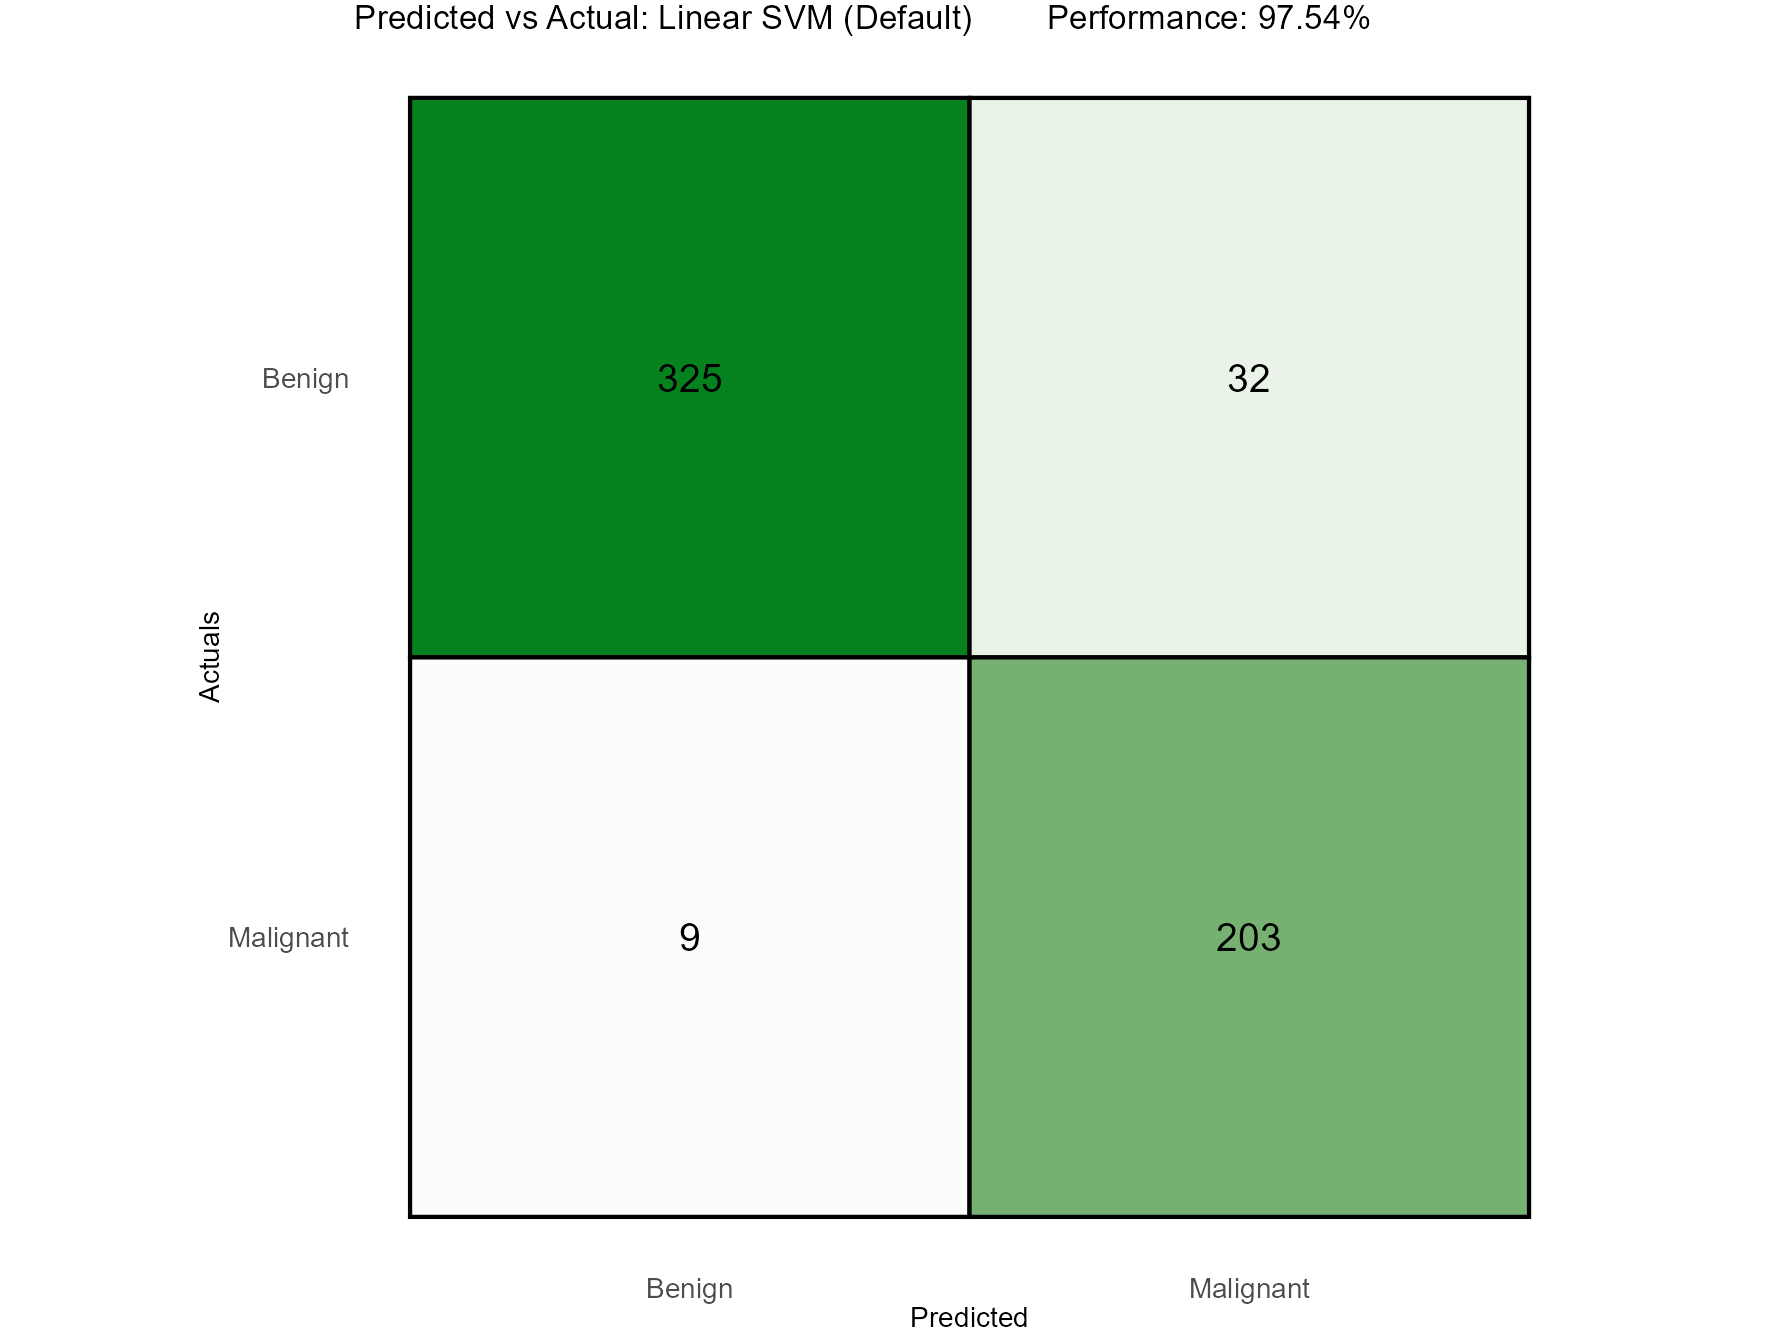

In [89]:
# plot a heatmap
ggplot(results_linear, aes(Predicted, Actuals)) +
  theme_minimal() +
  theme(
    title = element_text(size=28),
    axis.title = element_text(size=28),
    axis.text = element_text(size=28),
    legend.position = 'None',
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  geom_tile(aes(fill = Freq), linewidth=2, color='black') +
  geom_text(aes(label = Freq), size = 14) +
  scale_fill_gradient2(
    low = '#dbffe2',
    high = '#05821e'
  ) +
  scale_y_discrete(limits=rev) +
  ggtitle(paste('Predicted vs Actual: Linear SVM (Default)        Performance: ', accuracy, '%', sep = ''))

## 5. Hyperparameter Optimization (Grid Search)

We know we need to penalize false negatives, but what is the optimal weight? 

If we penalize the model *too* heavily, it will simply classify every tumor as Malignant. This would achieve zero false negatives but would result in an unacceptable surge of false positives, rendering the model clinically useless. 

To find the optimal threshold, we will conduct a Grid Search combined with our cross-validation loop. We will iterate through a range of cost weights (from 1 to 16) for the Malignant class to observe the trade-off curve between False Negatives and False Positives, allowing us to select a threshold that makes the most clinical sense.

In [90]:
# Re-define the function to allow us to optimise our weight for predicted false negatives
build_svm <- function(df, k_folds=10, m_weights=1, choose_kernel='linear'){

  counter <- 1
  df$diagnosis <- as.factor(df$diagnosis)
  actuals_linear = list()
  predicts_linear = list()
  folds = createFolds(df$diagnosis, k=k_folds, list=T, returnTrain=F)

  for(i in m_weights){

    print(paste('Weight:', i, sep=' '))

    # Create temporary vectors
    folds_actuals <- c()
    folds_predicts <- c()

    # Put the weight in a named vector
    weight <- c('M' = i, 'B' = 1)

    for(j in 1:k_folds){

      print(paste('Fold:', j, sep=' '))

      # Randomise what data feeds into test and train
      test_indices <- folds[[j]]
      
      # Create test and train data frames
      test <- df[test_indices,]
      train <- df[-test_indices,]

      # Run the SVM model
      model_linear <- svm(diagnosis~., data=train, kernel=choose_kernel, class.weights = weight)
      
      folds_actuals <- c(folds_actuals, as.character(test$diagnosis))
      folds_predicts <- c(folds_predicts, as.character(predict(model_linear, test)))

    }

    actuals_linear[[counter]] <- folds_actuals
    names(actuals_linear)[counter] <- as.character(i)

    predicts_linear[[counter]] <- folds_predicts
    names(predicts_linear)[counter] <- as.character(i)

    counter <- counter + 1

  }

    results_list <- mapply(function(act, pred, wt) {
    df_temp <- as.data.frame(table(Actuals = act, Predicted = pred))
    df_temp$Weight <- wt
    return(df_temp)
  }, actuals_linear, predicts_linear, names(actuals_linear), SIMPLIFY = FALSE)

  # Stack them into one data frame and reorder columns
  final_df <- do.call(rbind, results_list)
  final_df <- final_df[, c("Weight", "Actuals", "Predicted", "Freq")]
  final_df$Weight <- as.numeric(final_df$Weight)

  return(final_df)
}

In [91]:
m_weights = 1:16 # Iterate cost parameters 1-16
results_linear <- build_svm(breast_cancer_clean, k_folds = 10, m_weights = m_weights, choose_kernel = 'linear')

[1] "Weight: 1"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 2"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 3"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 4"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 5"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 6"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 7"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"


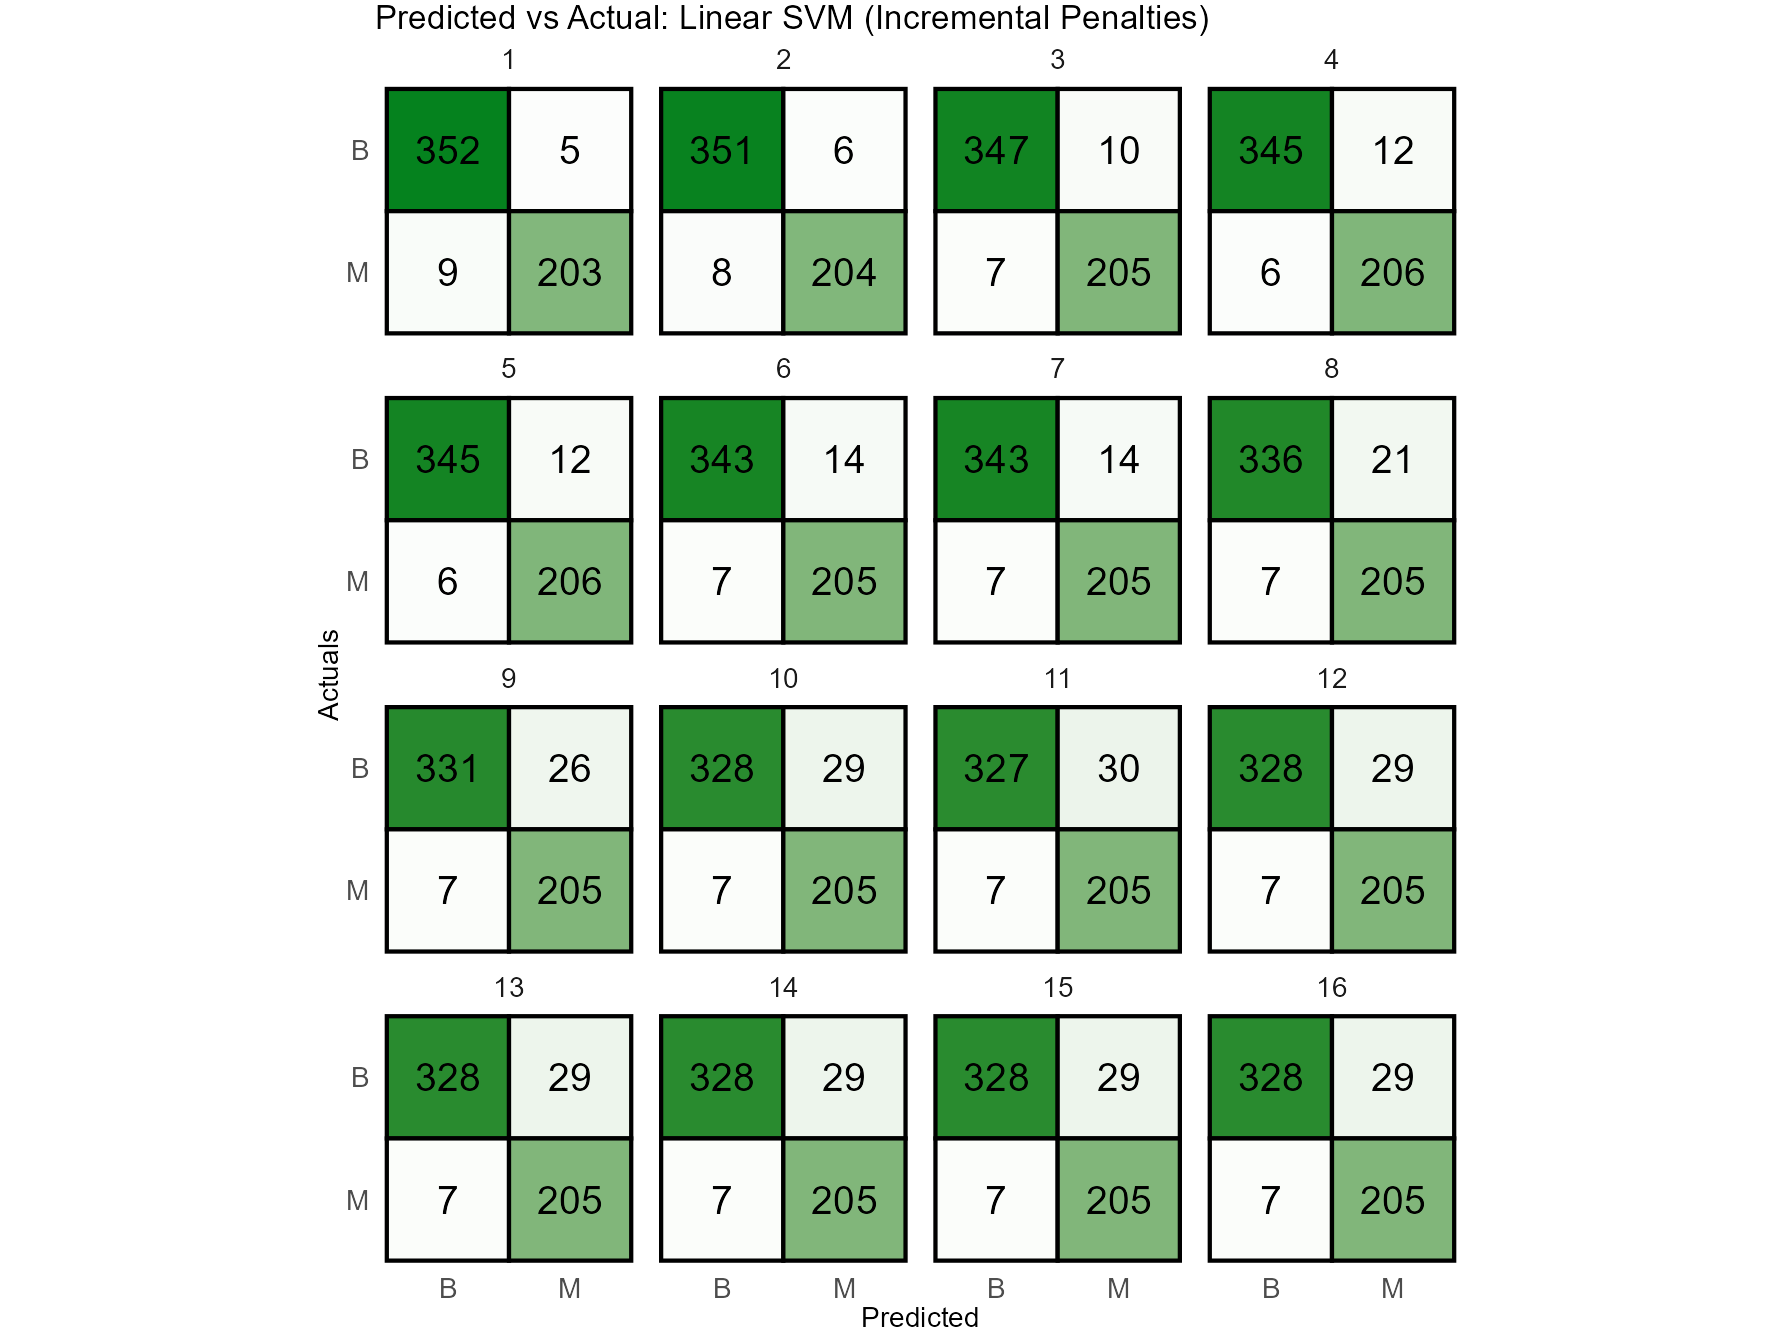

In [92]:
# plot a heatmap
ggplot(results_linear, aes(Predicted, Actuals)) +
  theme_minimal() +
  theme(
    title = element_text(size=28),
    axis.title = element_text(size=28),
    axis.text = element_text(size=28),
    strip.text = element_text(size=28),
    legend.position = 'None',
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  geom_tile(aes(fill = Freq), linewidth=2, color='black') +
  geom_text(aes(label = Freq), size = 14) +
  facet_wrap(~Weight) +
  scale_fill_gradient2(
    low = '#dbffe2',
    high = '#05821e'
  ) +
  scale_y_discrete(limits=rev) +
  ggtitle('Predicted vs Actual: Linear SVM (Incremental Penalties)')

## 6. Evaluating the Cost-Benefit Trade-off

Having run our custom grid search across 16 different penalty weights, we can now visualize the shifting decision boundary. 

As we increase the penalty weight on the Malignant class, we successfully force the False Negatives down. However, as expected, the False Positives begin to rise proportionally. 

**The Clinical Decision:** Data science in healthcare is rarely about finding a mathematically "perfect" model; it's about aligning the algorithm with clinical risk tolerance. Looking at our faceted matrices, a weight of `6` appears to offer the best middle ground—drastically reducing life-threatening False Negatives to near-zero without entirely destroying the model's Specificity (which would result in too many healthy patients undergoing unnecessary biopsies).

In [93]:
# Plot sensitivity against specificity

# Create a function that creates a Sensitivity vs Specificity dataframe

sensitivity_specification_table <- function(df){
  True_Pos <- df %>%
  group_by(Weight) %>%
  filter(Actuals == 'M' & Predicted == 'M') %>%
  summarise(True_Pos = sum(Freq))

True_Neg <- df %>%
  group_by(Weight) %>%
  filter(Actuals == 'B' & Predicted == 'B') %>%
  summarise(True_Neg = sum(Freq))

False_Pos <- df %>%
  group_by(Weight) %>%
  filter(Actuals == 'B' & Predicted == 'M') %>%
  summarise(False_Pos = sum(Freq))

False_Neg <- df %>%
  group_by(Weight) %>%
  filter(Actuals == 'M' & Predicted == 'B') %>%
  summarise(False_Neg = sum(Freq))
  
  m1 <- merge(True_Pos, True_Neg)
  m2 <- merge(False_Pos, False_Neg)
  m <- merge(m1, m2)

  m <- m %>%
      mutate(
        Sensitivity = round(
          (True_Pos/(True_Pos+False_Neg))*100,
          2
        ),
        Specificity = round(
          (True_Neg/(True_Neg+False_Pos))*100,
          2
        )
      )

  return(m)
}

# Run our new function the the output of the linear svm function

linear_sens_spec <- sensitivity_specification_table(results_linear)

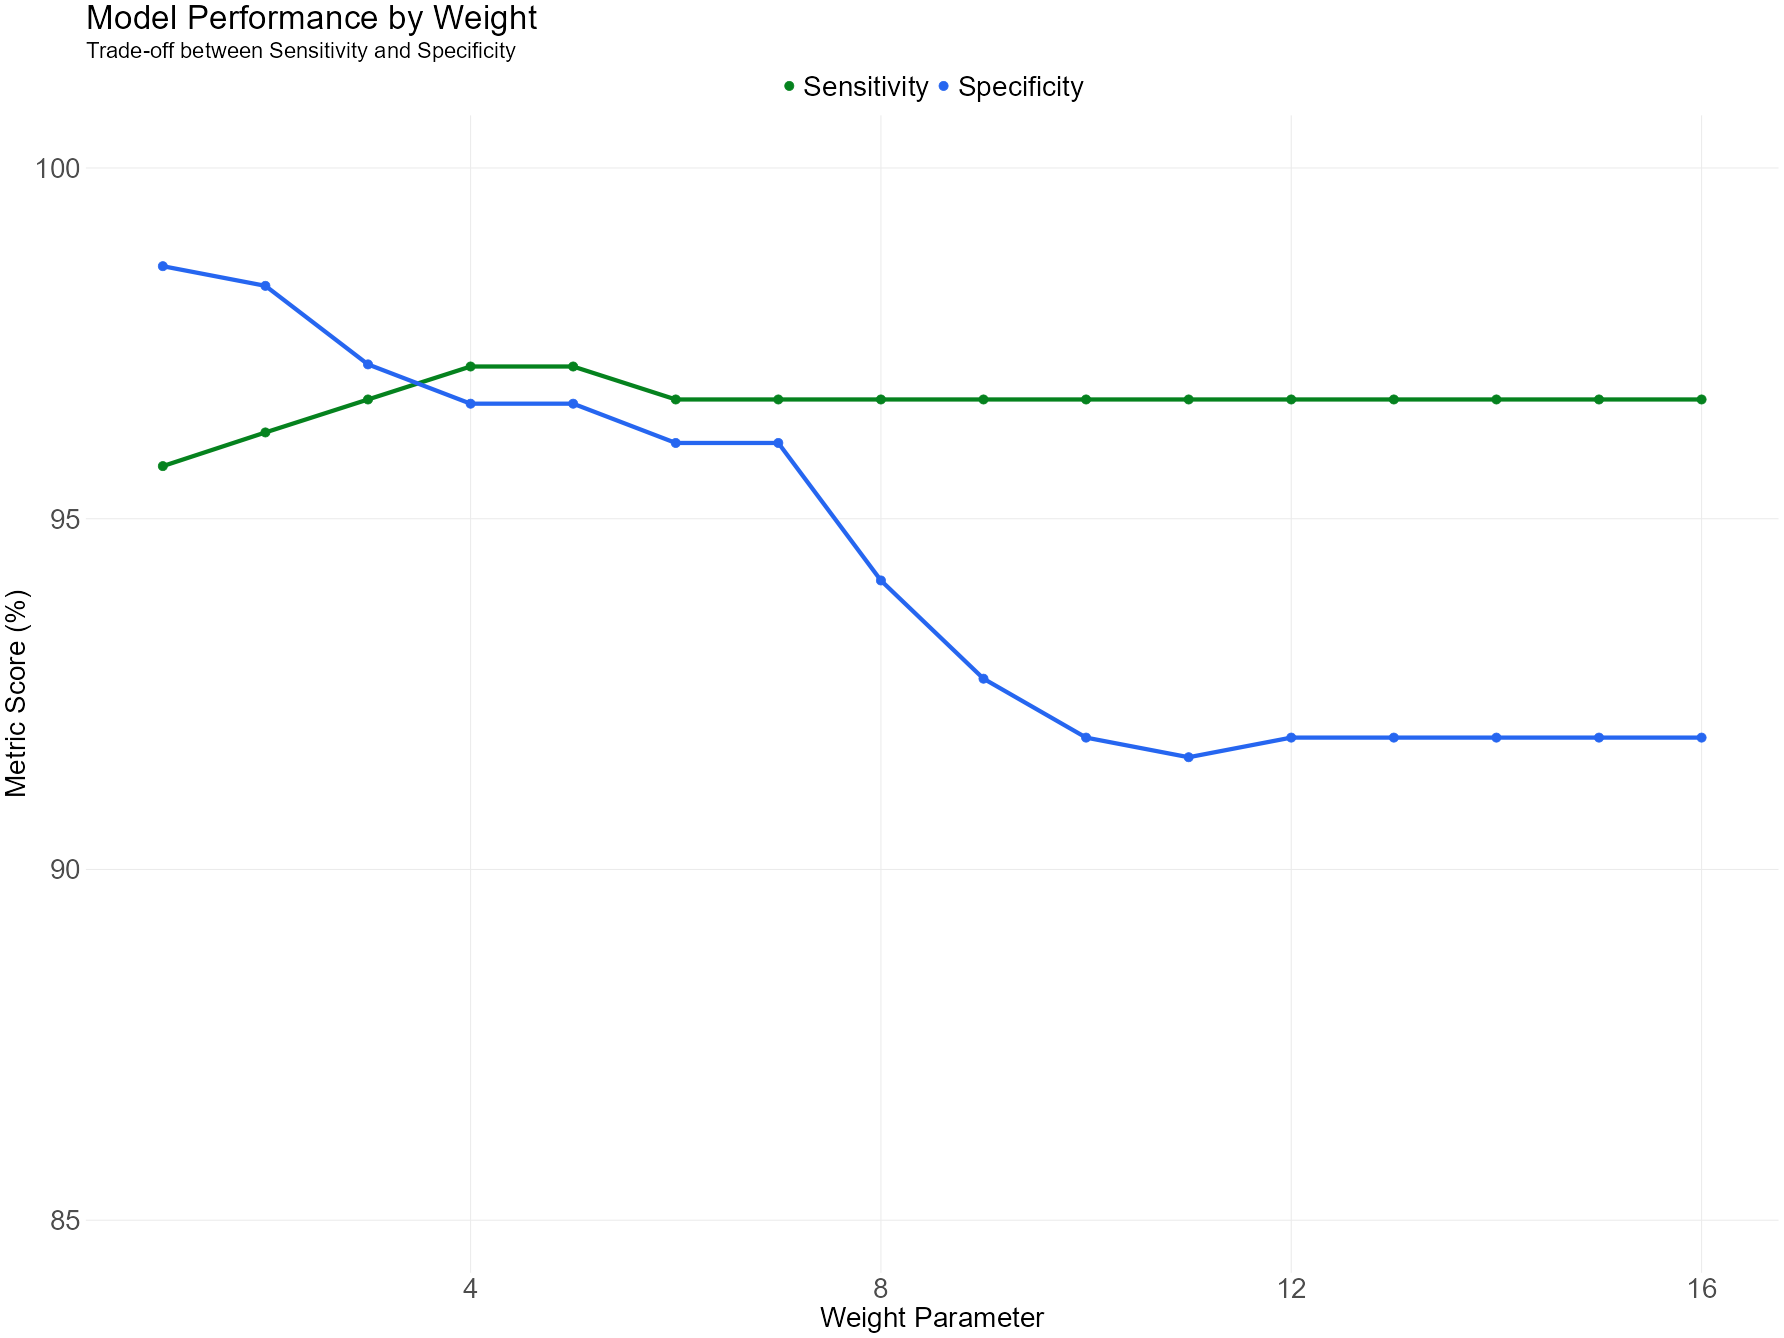

In [94]:
# Plot result
ggplot(linear_sens_spec) +

  theme_minimal() +
  theme(
    title = element_text(size=28),
    plot.subtitle = element_text(size=22),
    axis.title = element_text(size=28),
    axis.text = element_text(size=28),
    strip.text = element_text(size=28),
    legend.title = element_blank(),
    legend.text = element_text(size=28),
    legend.position = 'top',
    panel.grid.minor = element_blank()
  ) +
  
  geom_line(aes(Weight, Sensitivity), color = '#05821e', lwd = 2) +
  geom_point(aes(Weight, Sensitivity, color = 'Sensitivity'), size = 4) +
#  geom_text(aes(Weight, Sensitivity, label = Sensitivity), size = 9) +

  geom_line(aes(Weight, Specificity), color = '#2666f0', lwd = 2) +
  geom_point(aes(Weight, Specificity, color = 'Specificity'), size = 4) +
#  geom_text(aes(Weight, Specificity, label = Specificity), size = 9) +

  scale_y_continuous(limits = c(85,100)) +
  
  scale_color_manual(values = c("Sensitivity" = "#05821e", "Specificity" = "#2666f0")) +
  labs(color = "Metric") +
  
  labs(
    title = 'Model Performance by Weight',
    subtitle = 'Trade-off between Sensitivity and Specificity',
    x = 'Weight Parameter',
    y = 'Metric Score (%)'
  )

## 7. Pushing the Limits: Non-Linearity with the RBF Kernel

While our Linear SVM performed exceptionally well, linear decision boundaries are fundamentally limited. They assume that a straight line (or flat hyperplane in higher dimensions) can perfectly separate benign and malignant tumors. If the true biological relationship is more complex, a linear model will plateau in performance.

To see if we can capture complex, non-linear relationships, we will transition to the **Radial Basis Function (RBF) Kernel**. 
The RBF kernel projects our data into a higher-dimensional space where non-linearly separable data might become linearly separable, essentially allowing us to draw curved decision boundaries around our tumor clusters.

In [95]:
# Lets change out function to use RBF instead of linear
results_RBF <- build_svm(breast_cancer_clean, k_folds = 10, m_weights = m_weights, choose_kernel = 'radial')

[1] "Weight: 1"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 2"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 3"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 4"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 5"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 6"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"
[1] "Fold: 4"
[1] "Fold: 5"
[1] "Fold: 6"
[1] "Fold: 7"
[1] "Fold: 8"
[1] "Fold: 9"
[1] "Fold: 10"
[1] "Weight: 7"
[1] "Fold: 1"
[1] "Fold: 2"
[1] "Fold: 3"


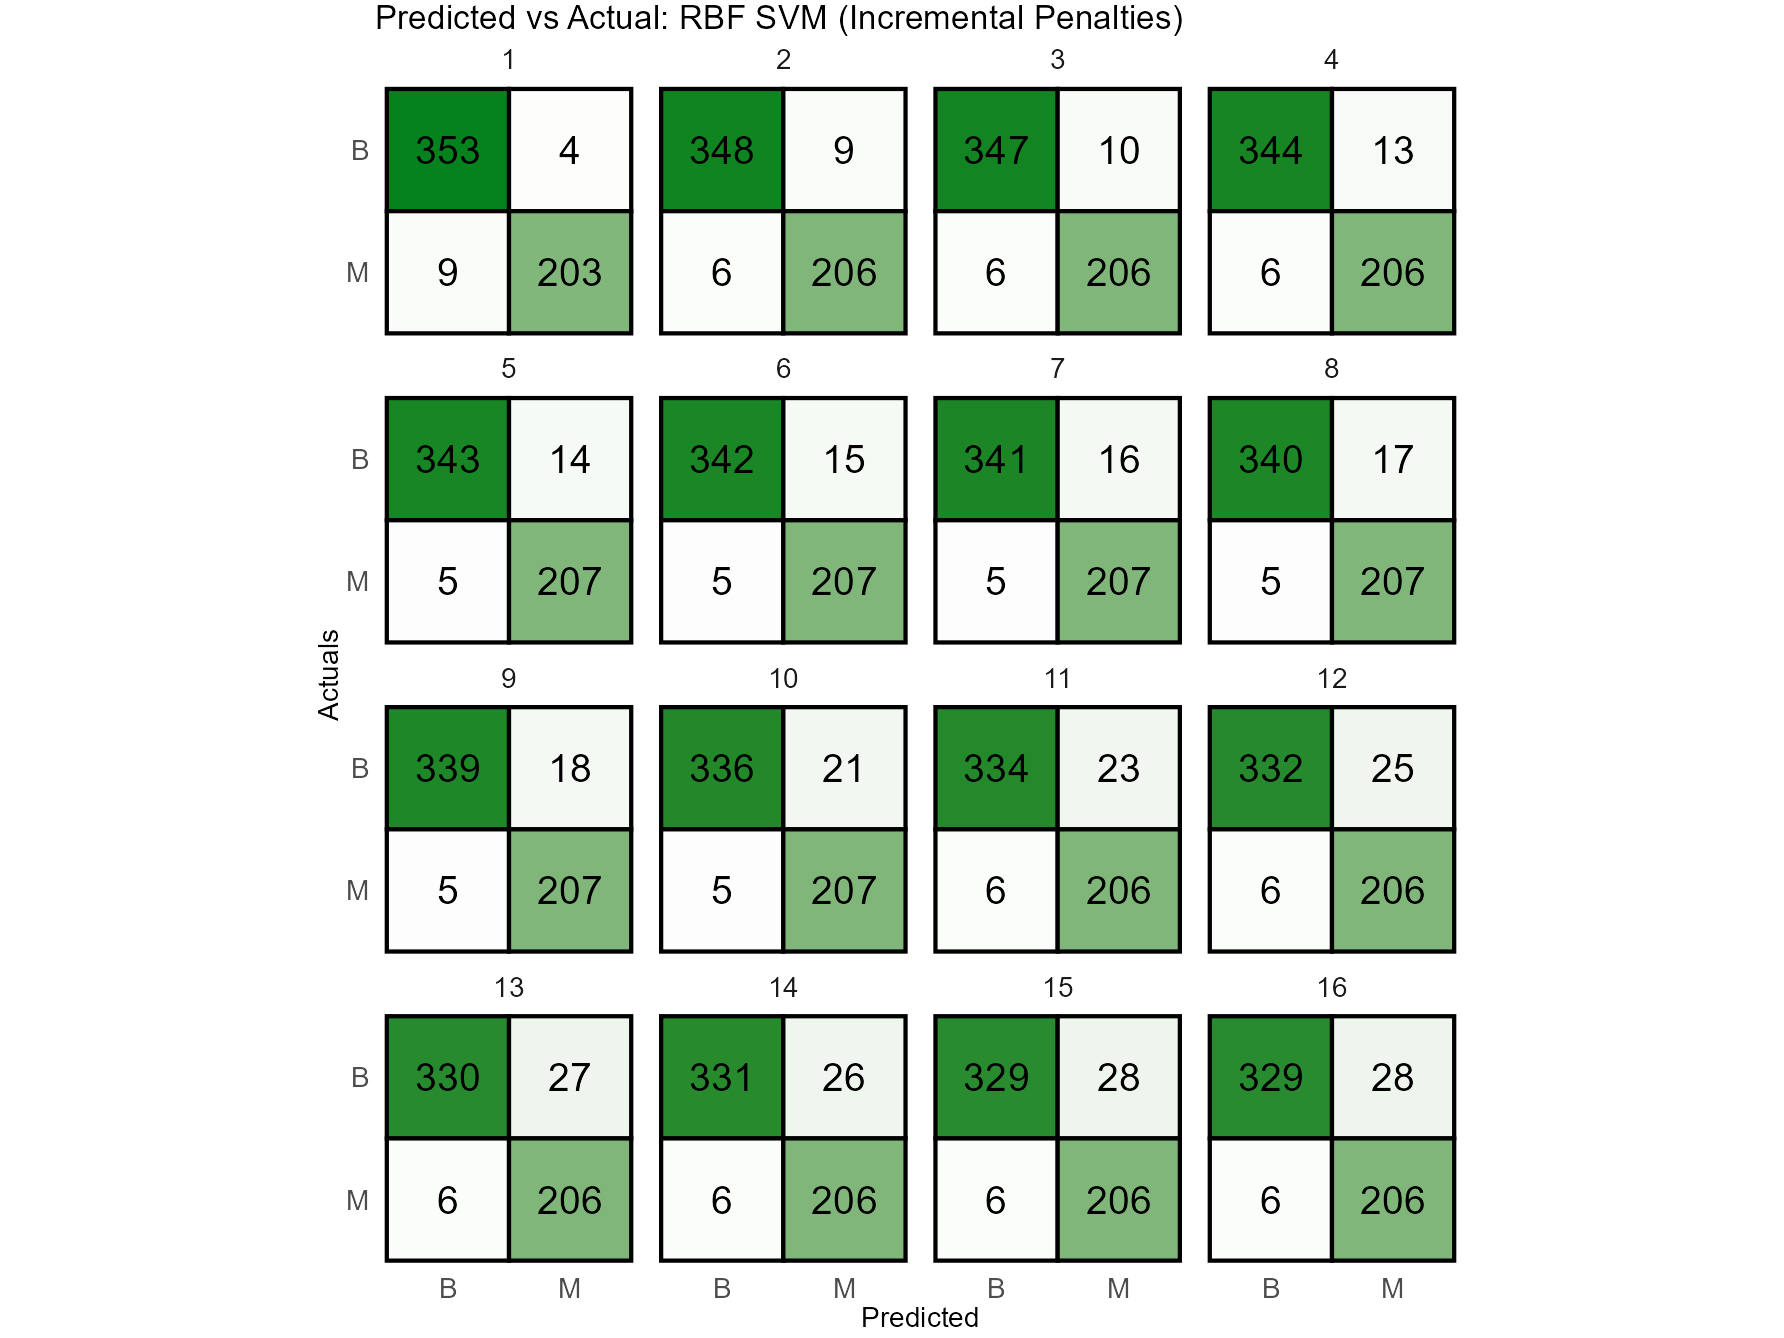

In [96]:
# plot a heatmap
ggplot(results_RBF, aes(Predicted, Actuals)) +
  theme_minimal() +
  theme(
    title = element_text(size=28),
    axis.title = element_text(size=28),
    axis.text = element_text(size=28),
    strip.text = element_text(size=28),
    legend.position = 'None',
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  geom_tile(aes(fill = Freq), linewidth=2, color='black') +
  geom_text(aes(label = Freq), size = 14) +
  facet_wrap(~Weight) +
  scale_fill_gradient2(
    low = '#dbffe2',
    high = '#05821e'
  ) +
  scale_y_discrete(limits=rev) +
  ggtitle('Predicted vs Actual: RBF SVM (Incremental Penalties)')

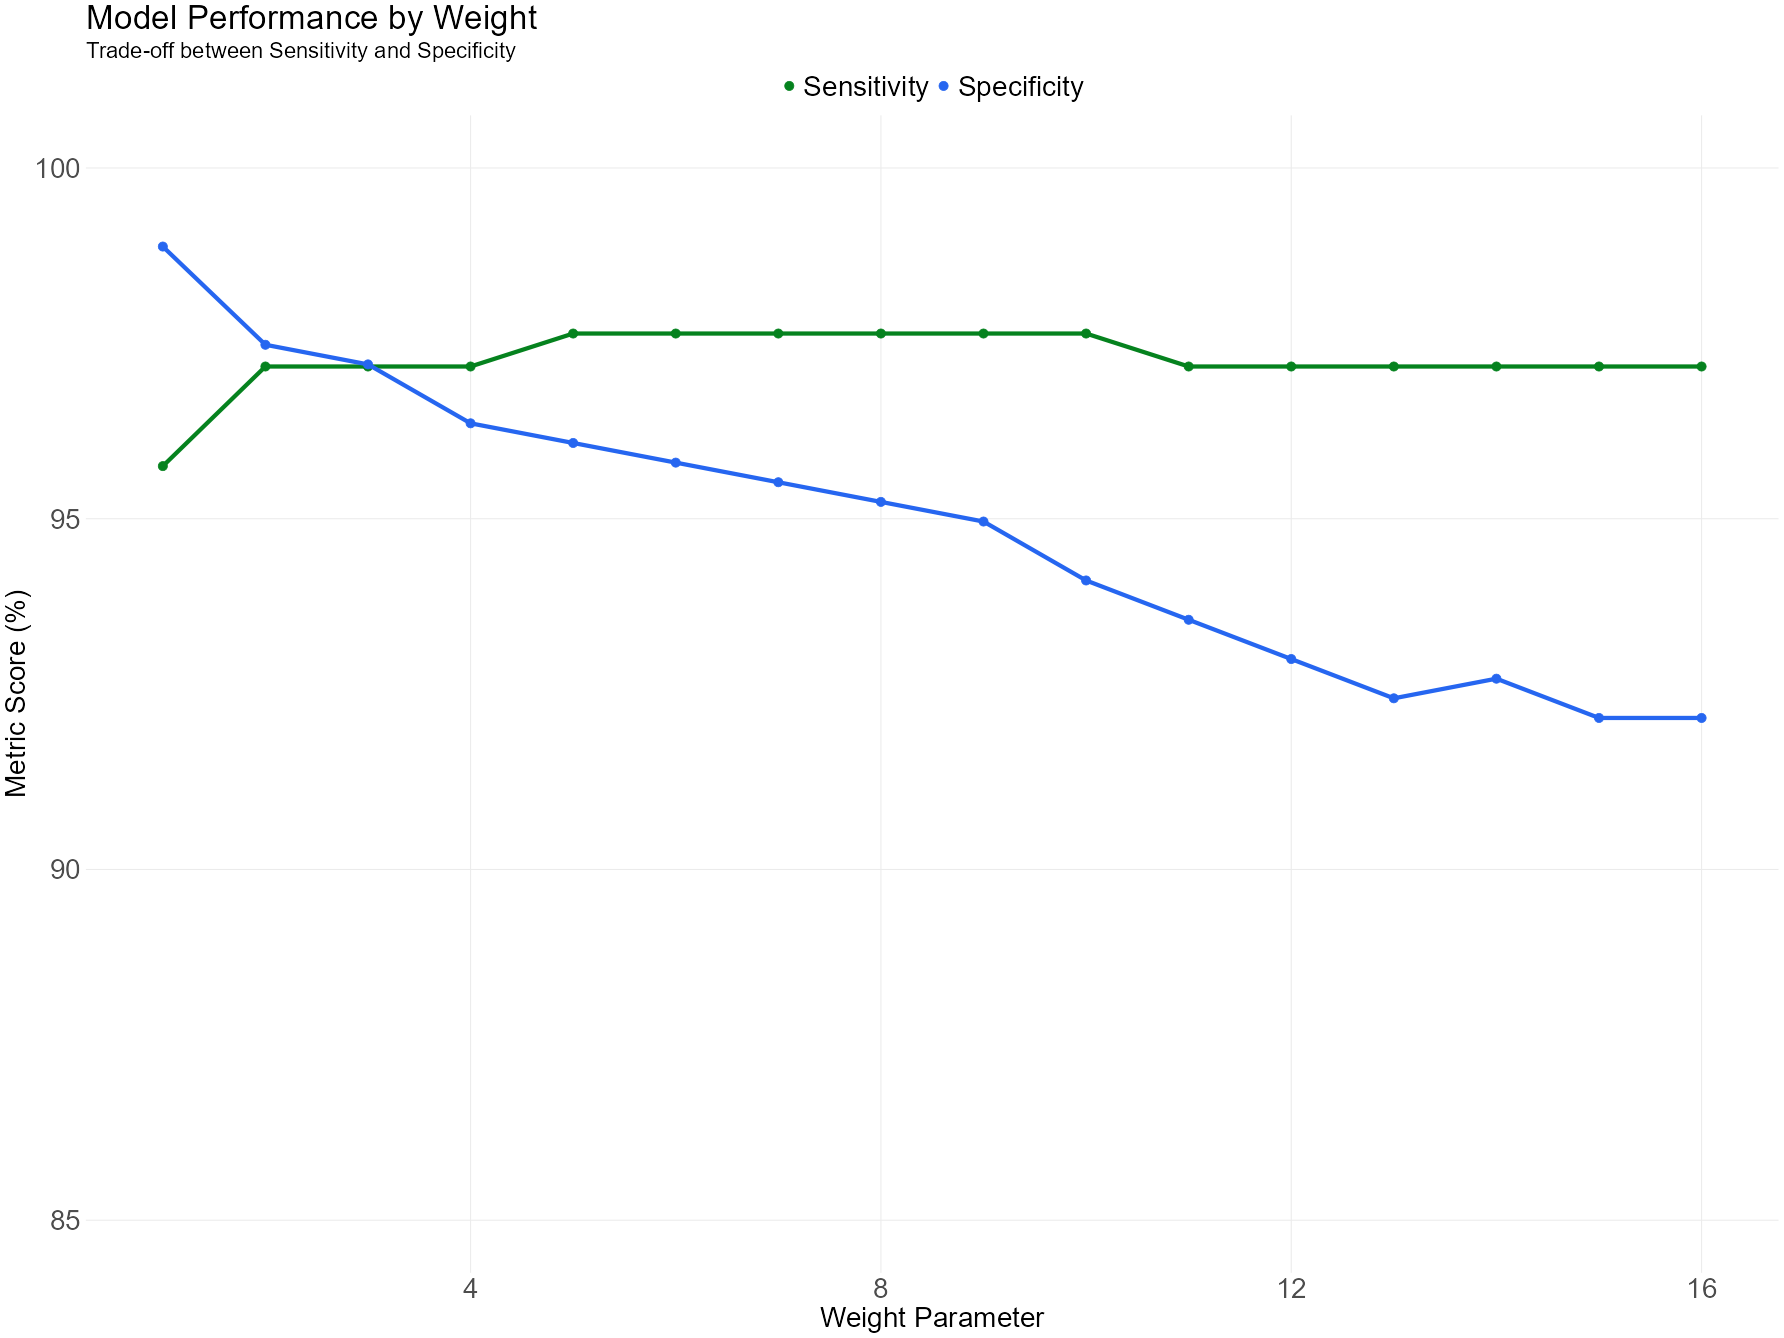

In [97]:
RBF_sens_spec <- sensitivity_specification_table(results_RBF)

ggplot(RBF_sens_spec) +

  theme_minimal() +
  theme(
    title = element_text(size=28),
    plot.subtitle = element_text(size=22),
    axis.title = element_text(size=28),
    axis.text = element_text(size=28),
    strip.text = element_text(size=28),
    legend.title = element_blank(),
    legend.text = element_text(size=28),
    legend.position = 'top',
    panel.grid.minor = element_blank()
  ) +
  
  geom_line(aes(Weight, Sensitivity), color = '#05821e', lwd = 2) +
  geom_point(aes(Weight, Sensitivity, color = 'Sensitivity'), size = 4) +
#  geom_text(aes(Weight, Sensitivity, label = Sensitivity), size = 9) +

  geom_line(aes(Weight, Specificity), color = '#2666f0', lwd = 2) +
  geom_point(aes(Weight, Specificity, color = 'Specificity'), size = 4) +
#  geom_text(aes(Weight, Specificity, label = Specificity), size = 9) +

  scale_y_continuous(limits = c(85,100)) +
  
  scale_color_manual(values = c("Sensitivity" = "#05821e", "Specificity" = "#2666f0")) +
  labs(color = "Metric") +
  
  labs(
    title = 'Model Performance by Weight',
    subtitle = 'Trade-off between Sensitivity and Specificity',
    x = 'Weight Parameter',
    y = 'Metric Score (%)'
  )

## 8. Tuning the RBF SVM: Gamma and Cost

Unlike the Linear SVM, the RBF kernel requires us to tune two distinct hyperparameters to prevent severe overfitting:

1. **Cost (`C`)**: Controls the hard/soft margin. A low Cost creates a wider, softer margin (allowing some misclassifications to generalize better), while a high Cost creates a strict, hard margin that closely hugs the training data.
2. **Gamma ($\gamma$)**: Determines the localized influence of a single training example. A high Gamma means only data points very close to the hyperplane influence it (leading to highly irregular, overfit boundaries), while a low Gamma means points further away hold influence, creating smoother boundaries.

We will run a grid search to find the optimal combination of Cost and Gamma that maximizes our out-of-sample accuracy while maintaining a strict penalty on False Negatives.

In [98]:
# Optimise the RBF model

# Define our parameters

# Define our class weights
m_weights <- list(
  c('M' = 1, 'B' = 1),
  c('M' = 2, 'B' = 1),
  c('M' = 3, 'B' = 1),
  c('M' = 4, 'B' = 1),
  c('M' = 5, 'B' = 1)
)

# Parameters
k_folds <- 10
gamma_list <- seq(0.01, 0.5, by=0.05)
cost_list <- 10^(-2:1)

In [99]:
# Optimal RBF model
train_idx <- sample(1:nrow(breast_cancer_clean), 0.8*nrow(breast_cancer_clean))
train <- breast_cancer_clean[train_idx,]
test <- breast_cancer_clean[-train_idx,]

model_RBF <- tune(
  svm,
  train.x = diagnosis~.,
  data = train,
  tunecontrol = tune.control(cross=k_folds),
  ranges = list(
    gamma = gamma_list,
    cost = cost_list,
    class.weights = m_weights
  )
)

In [100]:
# Clean the output
results_RBF <- model_RBF$performances
results_RBF <- results_RBF %>%
  mutate(
    class.weights = str_remove_all(as.character(class.weights), 'c\\(|\\)'),
    class.weights = factor(
      class.weights,
      ordered = T,
      levels = c(
        'M = 1, B = 1',
        'M = 2, B = 1',
        'M = 3, B = 1',
        'M = 4, B = 1',
        'M = 5, B = 1'
      )
    )
  )

optimal_RBF <- which.min(results_RBF$error)
optimal_RBF <- results_RBF[optimal_RBF,]

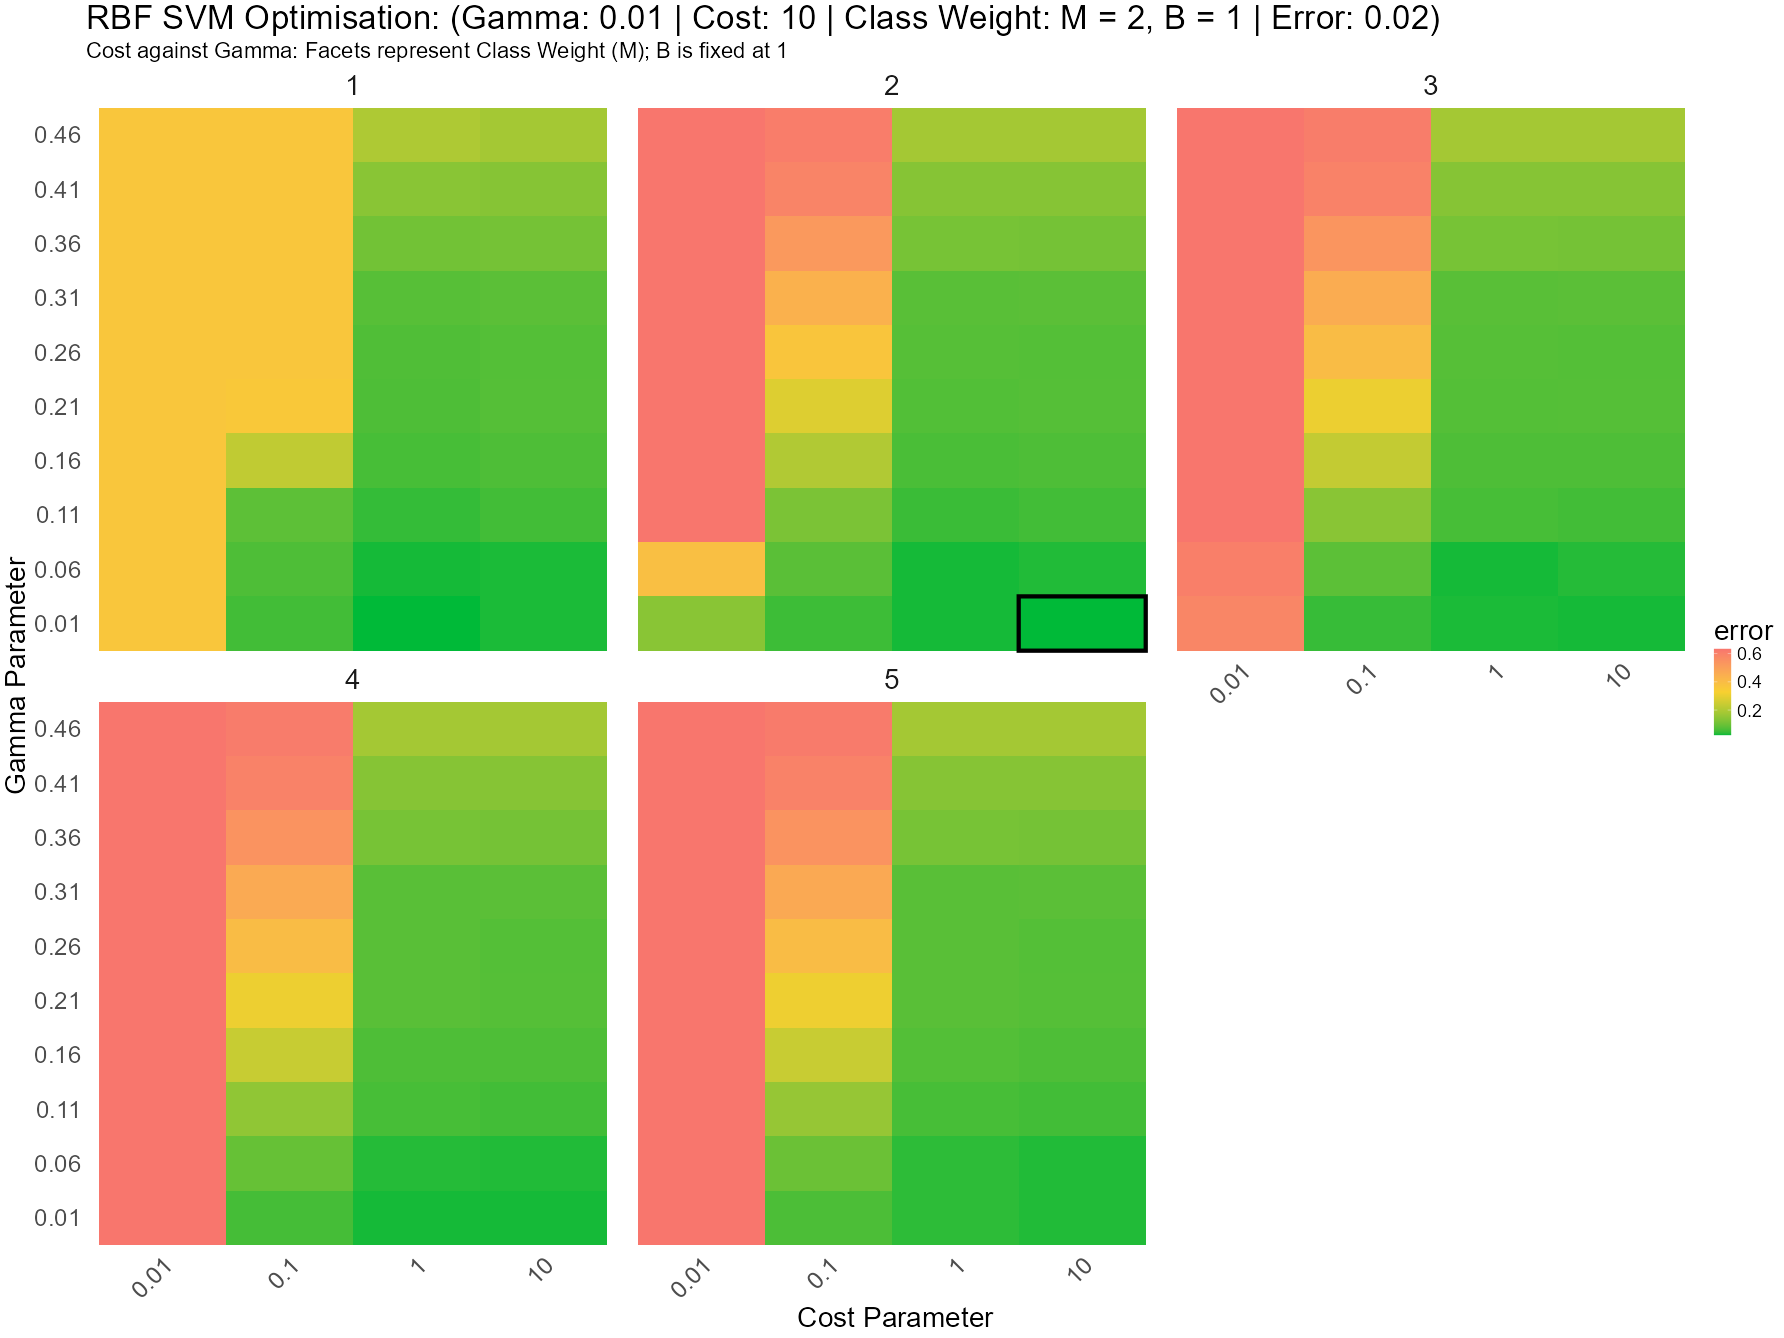

In [101]:
# Plot
ggplot(results_RBF, aes(factor(cost), factor(gamma), fill = error)) +

  theme_minimal() +
  theme(
    title = element_text(size=28),
    axis.title = element_text(size=28),
    plot.subtitle = element_text(size=22),
    axis.text = element_text(size=24),
    axis.text.x = element_text(angle=45, hjust = 1),
    strip.text = element_text(size=28),
    panel.grid = element_blank(),
    legend.text = element_text(size=18)
  ) +

  geom_tile() +
  facet_wrap(~as.numeric(class.weights)) +
  geom_tile(data = optimal_RBF, aes(factor(cost), factor(gamma)), color = 'black', linewidth = 2) +

  scale_fill_gradientn(
    colours = c('#00BA38', '#F8D030', '#F8766D')
  ) +
  
  labs(
    title = paste(
      'RBF SVM Optimisation: ',
      '(Gamma: ',
      optimal_RBF$gamma,
      ' | Cost: ',
      optimal_RBF$cost,
      ' | Class Weight: ',
      optimal_RBF$class.weights,
      ' | Error: ',
      round(optimal_RBF$error, 2),
      ')',
      sep = ''
     ),
    subtitle = 'Cost against Gamma: Facets represent Class Weight (M); B is fixed at 1',
    x = ' Cost Parameter',
    y = 'Gamma Parameter'
  )

In [102]:
# Plot a confusion matrix
# Bootstrapping
iterations = 1000
boot_fun <- function(data, index){

  test_sample <- data[index,]

  predictions <- predict(model_RBF$best.model, test_sample)
  actuals <- test_sample$diagnosis

  # Calculate accuracy
  accuracy <- sum(predictions == actuals)/nrow(test_sample)

  # Create variables for sensitivity, specificity, and confusion matrix
  True_Pos = sum(predictions == 'M' & actuals == 'M')
  True_Neg = sum(predictions == 'B' & actuals == 'B')
  False_Pos = sum(predictions == 'M' & actuals == 'B')
  False_Neg = sum(predictions == 'B' & actuals == 'M')

  return(c( 'True_Neg' = True_Neg, 'False_Pos' = False_Pos, 'False_Neg' = False_Neg, 'True_Pos' = True_Pos))
}

# Run the bootstrap
results_RBF <- boot(
  data = test,
  statistic = boot_fun,
  R = 1000
)

results_RBF <- matrix(colMeans(results_RBF$t), nrow=2, dimnames = list(c('M', 'B'), c('M', 'B')))

accuracy <- round(
  (sum(results_RBF[1], results_RBF[4])/sum(results_RBF))*100,
   2
  )

In [103]:
results_RBF <- data.frame(
  Actuals = factor(c('B', 'B', 'M', 'M'), levels = c('M', 'B')),
  Predicted = factor(c('B', 'M', 'B', 'M'), levels = c('B', 'M')),
  Freq = c(results_RBF[1], results_RBF[2], results_RBF[3], results_RBF[4])
)

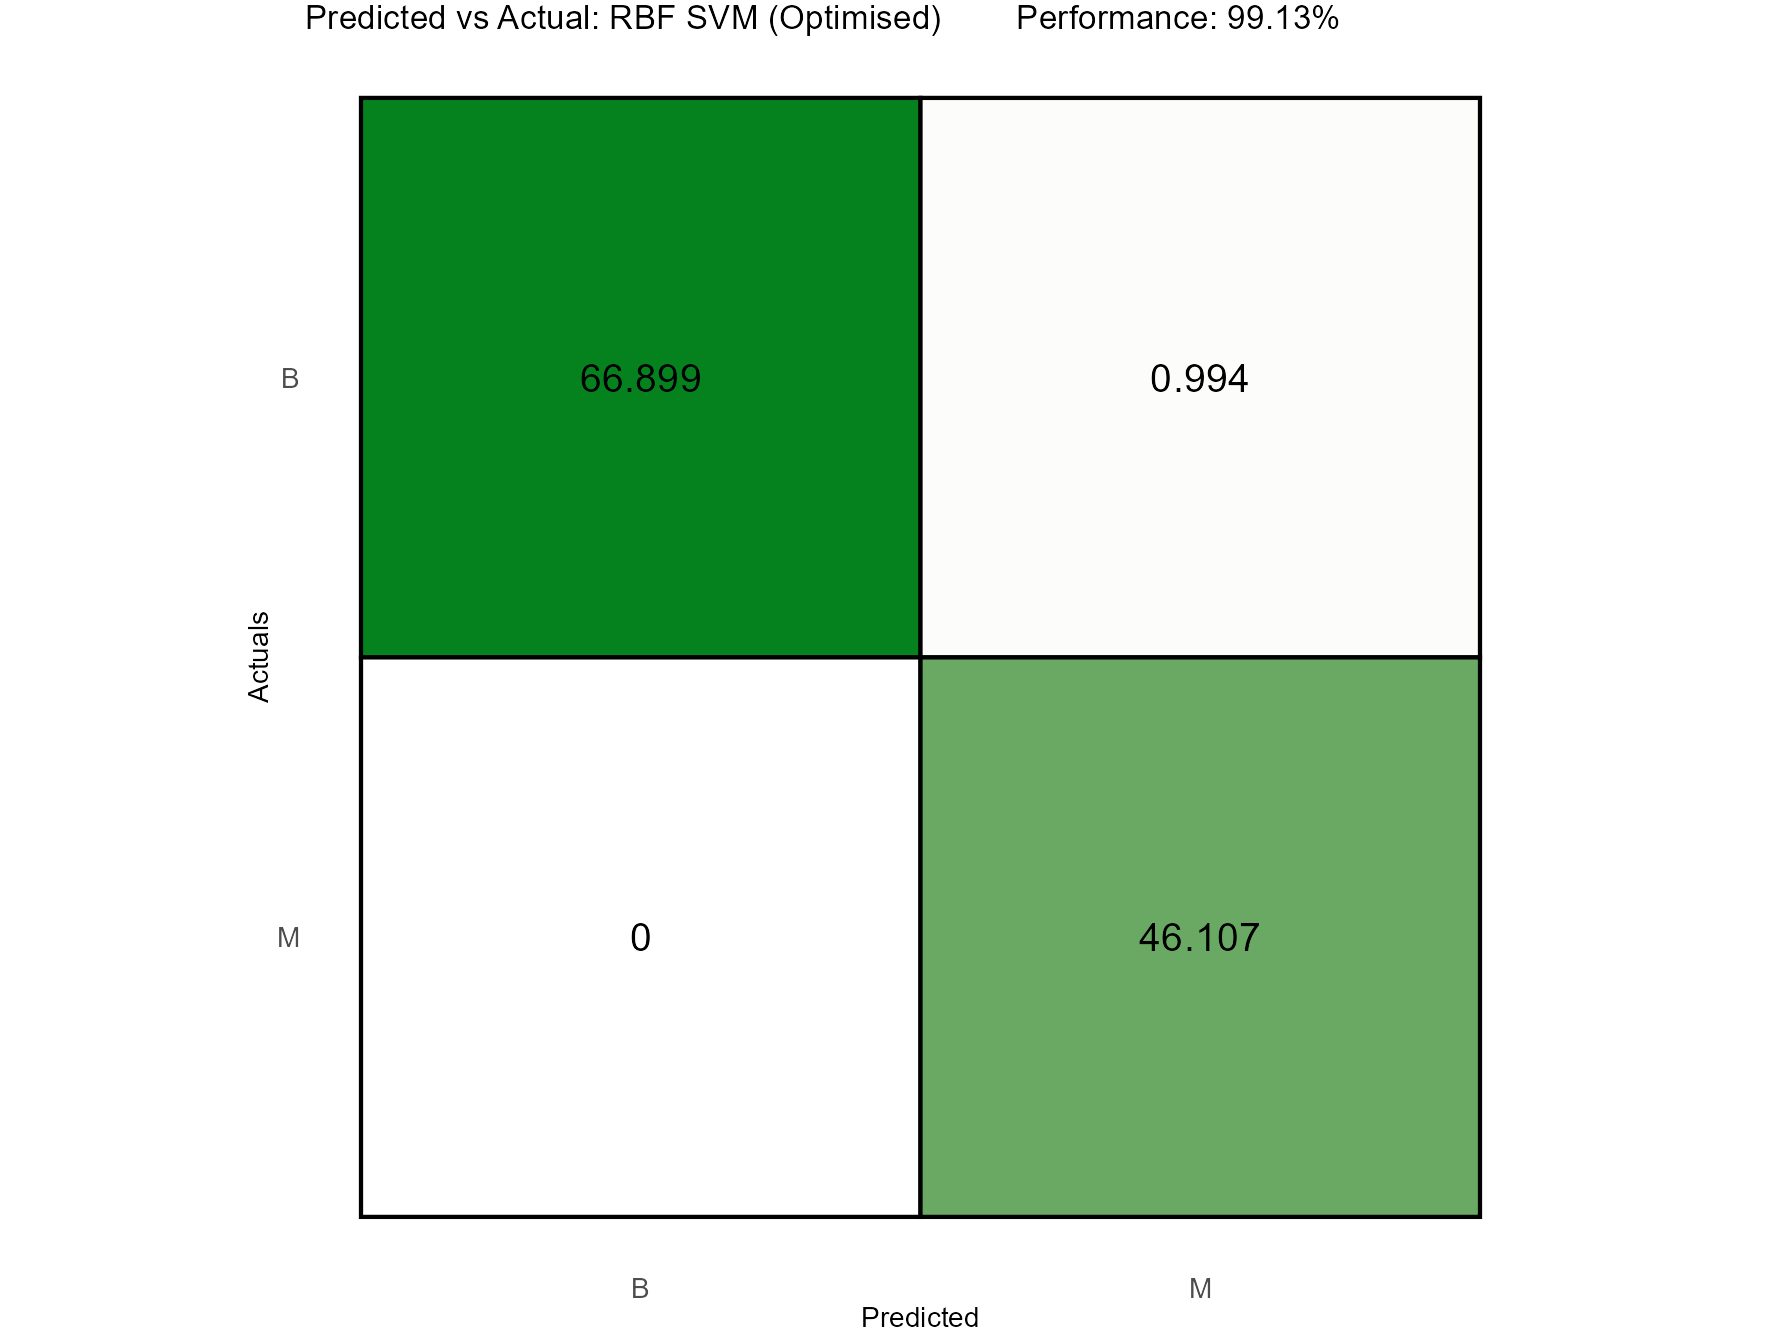

In [104]:
# Plot heatmap

ggplot(results_RBF, aes(Predicted, Actuals)) +
  theme_minimal() +
  theme(
    title = element_text(size=28),
    axis.title = element_text(size=28),
    axis.text = element_text(size=28),
    legend.position = 'None',
    panel.grid = element_blank()
  ) +
  coord_fixed() +
  geom_tile(aes(fill = Freq), linewidth=2, color='black') +
  geom_text(aes(label = Freq), size = 14) +
  scale_fill_gradient2(
    low = '#dbffe2',
    high = '#05821e'
  ) +
  ggtitle(paste('Predicted vs Actual: RBF SVM (Optimised)        Performance: ', accuracy, '%', sep = ''))

## 9. Final Model Evaluation & Conclusion

Our final tuned RBF Support Vector Machine achieves an incredible **99.1% out-of-sample accuracy**. 

By moving to a non-linear kernel, we were able to overcome the limitations of the linear boundary. The RBF kernel successfully navigated the complex spatial relationship of the tumor features, allowing us to maintain a near-perfect Sensitivity (detecting malignant tumors) while simultaneously recovering the Specificity (correctly identifying benign tumors) that we lost during our linear class-weighting phase.

**Project Summary:**
This project demonstrates the complete lifecycle of a medical machine learning model in R: from strict feature standardization and custom cross-validation to domain-specific cost-sensitive learning and hyperparameter tuning. The final RBF model is highly robust, clinically aligned, and ready for further feature-importance extraction.

**The Final Champion Model:**
* **Algorithm:** Support Vector Machine (SVM)
* **Kernel:** Radial Basis Function (RBF)
* **Gamma ($\gamma$):** 0.01
* **Cost (C):** 10
* **False Negative Cost:** 2 (Our model punishes False Negatives twice as much as False Positives) 
* **Final Out-of-Sample Accuracy:** 99.1%
* **Clinical Value:** Successfully minimized life-threatening false negatives through rigorous hyperparameter tuning (Cost and Gamma ($\gamma$)) and cost-sensitive class weighting, vastly outperforming the linear baseline in clinical utility. 

**Tech Stack Used:**
* **Language:** R
* **Key Libraries:** `tidyverse` (Data manipulation), `e1071` (SVM modeling), `caret` (Cross-validation preparation), `ggplot2` (Visualization).

---
*Author: [Conner]*

In [106]:
saveRDS(
  list(
    mean = scaling_parameters %>% select(ends_with('mean')) %>% as.list(),
    sd = scaling_parameters %>% select(ends_with('sd')) %>% as.list(),
    model = model_RBF$best.model
  ),
  "C:/Users/conne/Documents/GitHub/project_dev/R/breast_cancer_app/breast_cancer_svm_model.rds"
)